# Yambda EDA — поиск инсайтов для feature engineering

Цель: каждая секция заканчивается явным feature/architecture/heuristic implication для следующих фаз ранкера.

Текущее состояние: A2.2 даёт val=387.55, public=304.48. Top-feature `pair_days_since_last_listen` (10.2%). Hint от пользователя: pair-features дают max impact — копаем глубже + добавляем percentiles.

**Структура:**
1. Cohort decomposition val GT — где источник метрики
2. Time decay validation — правильный `half_life_units`
3. Played-ratio threshold — валидация 50% порога
4. Likes timing → RecentLikes tau
5. Pair-feature deep dive (почему `pair_days_since_last_listen` доминирует)
6. **Новые pair-features** (decay_listens, listens_per_day, share_recent)
7. **Percentile features** (q15/q50/q85)
8. is_organic — separate signal или conditioning
9. Track length effect (нормализация completion)
10. Cold-tier characterization
11. Item co-listen patterns (item2vec-like)
12. **Final summary** — ranked feature additions

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from src.data.dataset import (
    load_listens, load_likes, load_dislikes, load_unlikes, load_undislikes,
    load_artist_item_mapping, load_album_item_mapping,
    positive_listens,
)
from src.data.splits import temporal_split

ONE_DAY_TS = 17_280
pl.Config.set_tbl_rows(20)
print('polars', pl.__version__)

polars 1.31.0


In [2]:
# Load all interaction tables — keep originals for full-period analysis
listens = load_listens('50m')
likes = load_likes('50m')
dislikes = load_dislikes('50m')
unlikes = load_unlikes('50m')
undislikes = load_undislikes('50m')
artist_map = load_artist_item_mapping()
album_map = load_album_item_mapping()
users = pl.read_csv('submissions/users.csv').get_column('uid').cast(pl.Int64).to_list()

pos = positive_listens(listens)
split = temporal_split(pos, val_days=7, gap_days=1)
cutoff_ts = int(split.train['timestamp'].max())

print(f'listens={len(listens):>11,d}  positive={len(pos):>11,d}')
print(f'likes={len(likes):>11,d}  dislikes={len(dislikes):>11,d}  unlikes={len(unlikes):>11,d}  undislikes={len(undislikes):>11,d}')
print(f'split.train={len(split.train):>11,d}  split.val={len(split.val):>11,d}  split.test={len(split.test):>11,d}')
print(f'cutoff_ts={cutoff_ts}  ({cutoff_ts/ONE_DAY_TS:.1f} days from origin)')
print(f'eval users (10k): {len(users)}')

listens= 46,467,212  positive= 29,370,391
likes=    881,456  dislikes=    107,776  unlikes=    312,972  undislikes=     21,033
split.train= 29,107,723  split.val=    229,650  split.test=    221,875
cutoff_ts=25861755  (1496.6 days from origin)
eval users (10k): 10000


## 1. Cohort decomposition val GT — где источник метрики

Для каждого eval user и его val GT items — куда они попадают?
- `repeats` — item уже встречался в train history юзера
- `fav_artist_new` — item новый, но артист был в train
- `fav_album_new` — item новый, но альбом был в train
- `cold` — ничего из вышеперечисленного

In [3]:
users_df = pl.DataFrame({'uid': users}).with_columns(pl.col('uid').cast(pl.Int64))

gt_val = (
    split.val
    .select(['uid', 'item_id'])
    .with_columns([pl.col('uid').cast(pl.Int64), pl.col('item_id').cast(pl.Int64)])
    .filter(pl.col('uid').is_in(users))
    .unique()
)

user_train_items = (
    split.train.select(['uid', 'item_id'])
    .with_columns([pl.col('uid').cast(pl.Int64), pl.col('item_id').cast(pl.Int64)])
    .filter(pl.col('uid').is_in(users))
    .unique()
)

# Map item → primary artist/album
art_primary = artist_map.group_by('item_id').agg(pl.col('artist_id').min()).with_columns(pl.col('item_id').cast(pl.Int64))
alb_primary = album_map.group_by('item_id').agg(pl.col('album_id').min()).with_columns(pl.col('item_id').cast(pl.Int64))

user_train_artists = user_train_items.join(art_primary, on='item_id', how='inner').select(['uid', 'artist_id']).unique()
user_train_albums  = user_train_items.join(alb_primary, on='item_id', how='inner').select(['uid', 'album_id']).unique()

gt_with_meta = (
    gt_val
    .join(user_train_items.with_columns(pl.lit(1, dtype=pl.Int8).alias('in_train')), on=['uid', 'item_id'], how='left')
    .join(art_primary, on='item_id', how='left')
    .join(alb_primary, on='item_id', how='left')
    .join(user_train_artists.with_columns(pl.lit(1, dtype=pl.Int8).alias('artist_in_train')), on=['uid', 'artist_id'], how='left')
    .join(user_train_albums.with_columns(pl.lit(1, dtype=pl.Int8).alias('album_in_train')), on=['uid', 'album_id'], how='left')
    .with_columns([
        pl.col('in_train').fill_null(0),
        pl.col('artist_in_train').fill_null(0),
        pl.col('album_in_train').fill_null(0),
    ])
    .with_columns(
        pl.when(pl.col('in_train') == 1).then(pl.lit('repeat'))
        .when(pl.col('album_in_train') == 1).then(pl.lit('fav_album_new'))
        .when(pl.col('artist_in_train') == 1).then(pl.lit('fav_artist_new'))
        .otherwise(pl.lit('cold'))
        .alias('cohort')
    )
)

decomp = (
    gt_with_meta.group_by('cohort').agg(pl.len().alias('n')).sort('n', descending=True)
    .with_columns((pl.col('n') / pl.col('n').sum() * 100).round(2).alias('pct'))
)
decomp

cohort,n,pct
str,u32,f64
"""repeat""",128190,65.59
"""cold""",31038,15.88
"""fav_artist_new""",23981,12.27
"""fav_album_new""",12244,6.26


**Implications:**
- Если `repeat` > 50% — pair-features (`pair_n_listens`, `pair_days_since_last_listen`) объясняют большую часть метрики, что подтверждает feature importance из A2.2.
- Если `fav_artist_new` существенный (>15%) — поднять `top_entities` в ArtistAlbumPop.
- Если `cold` > 20% — нужен AudioEmbedKNN (Phase A3).
- `fav_album_new` — может стоит добавить отдельный AlbumPop CG (сейчас только Artist).

## 2. Time decay validation

Эмпирическая P(re-listen of item X by user U в течение 7 дней | last listen было T дней назад). Half-life даёт правильный `half_life_units`.

In [4]:
# For each (uid, item_id) pair in train, compute time gap between consecutive listens of the same pair.
# Then for each gap, see if there's any next listen within 7 days. This gives the decay function empirically.

pair_listens = (
    split.train
    .select(['uid', 'item_id', 'timestamp'])
    .with_columns([pl.col('uid').cast(pl.Int64), pl.col('item_id').cast(pl.Int64)])
    .sort(['uid', 'item_id', 'timestamp'])
)

pair_with_next = pair_listens.with_columns([
    pl.col('timestamp').shift(-1).over(['uid', 'item_id']).alias('next_ts')
]).with_columns([
    ((pl.col('next_ts') - pl.col('timestamp')) / ONE_DAY_TS).alias('gap_days'),
])

# For each starting listen, did the user re-listen within 7 days?
pair_with_next = pair_with_next.with_columns(
    pl.when(pl.col('gap_days').is_null()).then(0)
      .when(pl.col('gap_days') <= 7).then(1)
      .otherwise(0)
      .cast(pl.Int8).alias('relisten_7d')
)

# Now we need: P(any subsequent listen within 7 days | T days since this one).
# Approach: for each listen at time t, look at user's other listens of same item in (t, t+7d].
# Simpler: bin (uid, item_id) by max-pair-recency and compute relisten share via the pair_with_next view.
# We use a different framing: among pairs where user listened at least twice, plot the 1st gap distribution.

gap_bins = [0.5, 1, 2, 3, 5, 7, 14, 30, 60]
non_null_gaps = pair_with_next.filter(pl.col('gap_days').is_not_null())['gap_days'].to_numpy()
print(f'pairs with ≥2 listens: {len(non_null_gaps):,}')
print(f'median gap = {np.median(non_null_gaps):.2f} days, mean = {non_null_gaps.mean():.2f}')

# Cumulative distribution: what share of all next-listens come within T days?
for T in gap_bins:
    share = (non_null_gaps <= T).mean()
    print(f'P(next listen within {T:>4} days) = {share:.3f}')

pairs with ≥2 listens: 20,162,187
median gap = 35.57 days, mean = 94.34
P(next listen within  0.5 days) = 0.104
P(next listen within    1 days) = 0.133


P(next listen within    2 days) = 0.163
P(next listen within    3 days) = 0.185
P(next listen within    5 days) = 0.236
P(next listen within    7 days) = 0.269
P(next listen within   14 days) = 0.338
P(next listen within   30 days) = 0.462
P(next listen within   60 days) = 0.622


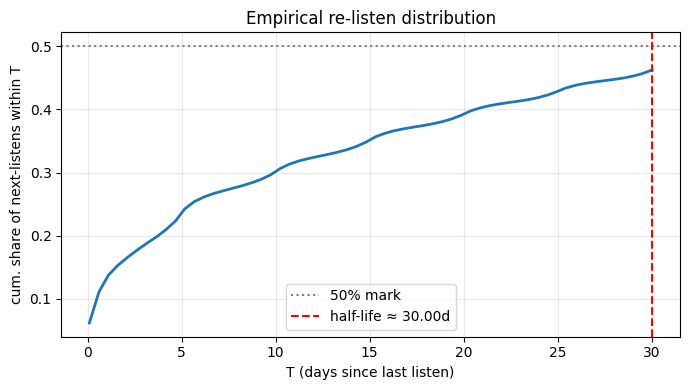


empirical half-life ≈ 30.00 days = 518400 timestamp units
currently using half_life_units=86400 = 5.0 days in DecayPop/Repeat/RecentLikes


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
Ts = np.linspace(0.1, 30, 60)
shares = [(non_null_gaps <= T).mean() for T in Ts]
ax.plot(Ts, shares, lw=2)
ax.axhline(0.5, color='gray', ls=':', label='50% mark')
# Find empirical "half-life": T at which cumulative share = 0.5
half_life_days = np.interp(0.5, shares, Ts)
ax.axvline(half_life_days, color='red', ls='--', label=f'half-life ≈ {half_life_days:.2f}d')
ax.set_xlabel('T (days since last listen)')
ax.set_ylabel('cum. share of next-listens within T')
ax.set_title('Empirical re-listen distribution')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'\nempirical half-life ≈ {half_life_days:.2f} days = {int(half_life_days * ONE_DAY_TS)} timestamp units')
print(f'currently using half_life_units=86400 = {86400/ONE_DAY_TS:.1f} days in DecayPop/Repeat/RecentLikes')

**Implication:** если эмпирическая half-life существенно отличается от 5 дней (текущая `half_life_units=86400`), скорректировать в `configs/model/{repeat,pop,recent_likes}.yaml`. Optuna в Phase D финализирует.

## 3. Played-ratio threshold sensitivity

Текущая граница `played_ratio_pct > 50` для positive listens. Авторы датасета предупреждают: «Thresholding at 50% loses signal; consider treating as regression target».

Тест: какая доля val GT pairs приходит из train listens с разным cutoff?

         skip (<30%):  15,331,869 (33.0%)
              30-50%:   1,764,952 (3.8%)
              50-80%:   1,853,442 (4.0%)
              80-99%:   2,564,690 (5.5%)
    completed (≥100):  24,952,259 (53.7%)
     replayed (>100):     218,145 (0.5%)


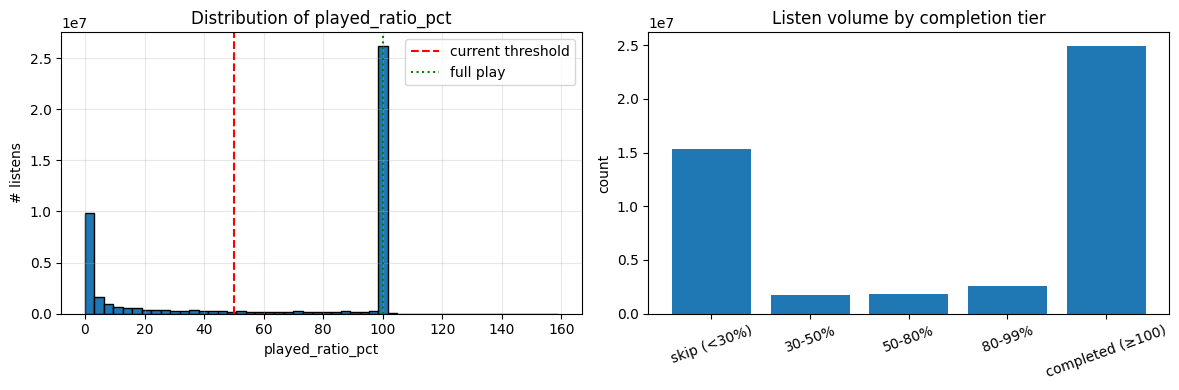

In [6]:
# Distribution of played_ratio_pct
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.clip(listens['played_ratio_pct'].to_numpy(), 0, 200), bins=50, edgecolor='k')
axes[0].axvline(50, color='red', ls='--', label='current threshold')
axes[0].axvline(100, color='green', ls=':', label='full play')
axes[0].set_xlabel('played_ratio_pct'); axes[0].set_ylabel('# listens'); axes[0].set_title('Distribution of played_ratio_pct')
axes[0].legend(); axes[0].grid(alpha=0.3)

# How many listens at each tier?
tiers = [
    ('skip (<30%)', listens.filter(pl.col('played_ratio_pct') < 30).height),
    ('30-50%', listens.filter((pl.col('played_ratio_pct') >= 30) & (pl.col('played_ratio_pct') <= 50)).height),
    ('50-80%', listens.filter((pl.col('played_ratio_pct') > 50) & (pl.col('played_ratio_pct') <= 80)).height),
    ('80-99%', listens.filter((pl.col('played_ratio_pct') > 80) & (pl.col('played_ratio_pct') <= 99)).height),
    ('completed (≥100)', listens.filter(pl.col('played_ratio_pct') >= 100).height),
    ('replayed (>100)', listens.filter(pl.col('played_ratio_pct') > 100).height),
]
for name, n in tiers:
    print(f'{name:>20}: {n:>11,d} ({n/len(listens)*100:.1f}%)')

axes[1].bar([t[0] for t in tiers[:5]], [t[1] for t in tiers[:5]])
axes[1].set_ylabel('count'); axes[1].set_title('Listen volume by completion tier')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [7]:
# What share of val GT pairs is reachable if we used cutoff X?
# Specifically: for each val GT (uid, item), do we see this user listened to this item in train at >= X%?

for thr in [30, 50, 70, 90, 100]:
    seen_at_thr = (
        listens
        .filter(pl.col('timestamp') < cutoff_ts)
        .filter(pl.col('played_ratio_pct') > thr)
        .select(['uid', 'item_id'])
        .with_columns([pl.col('uid').cast(pl.Int64), pl.col('item_id').cast(pl.Int64)])
        .unique()
    )
    hits = gt_val.join(seen_at_thr, on=['uid', 'item_id'], how='inner').height
    print(f'threshold > {thr:>3}: {hits:>6,d} val-GT pairs reachable as repeats ({hits/gt_val.height*100:.1f}%); train rows {seen_at_thr.height:>10,d}')

threshold >  30: 129,076 val-GT pairs reachable as repeats (66.0%); train rows  9,397,230


threshold >  50: 128,190 val-GT pairs reachable as repeats (65.6%); train rows  8,945,533


threshold >  70: 127,139 val-GT pairs reachable as repeats (65.0%); train rows  8,677,884


threshold >  90: 125,955 val-GT pairs reachable as repeats (64.4%); train rows  8,444,288
threshold > 100:  6,010 val-GT pairs reachable as repeats (3.1%); train rows    139,290


**Implications:**
- Сравниваем сколько val-GT "повторов" покрывается train-history при разных thr. Если thr=30 даёт +X% покрытия → стоит понизить порог.
- Если thr=70 покрывает почти столько же — можно сэкономить compute на 500m/5b.
- **Альтернатива по совету авторов**: использовать `played_ratio_pct` как continuous regression target в pair-фичах (уже частично делаем через `pair_avg/max_played_ratio`).

## 4. Likes timing → tau для RecentLikes

Per-user распределение интервалов между лайками. Сейчас `RecentLikes.half_life_units=86400` (5 дней) — то же что DecayPop. Hypothesis: лайки decay медленнее (юзер реже лайкает но это сильный сигнал).

users with at least 1 like: 8,270
days since last like — median 38.47, q25 10.34, q75 134.77, p95 701.14

inter-like gaps — median 0.03d, q25 0.000d, q75 3.63d, p95 37.42d


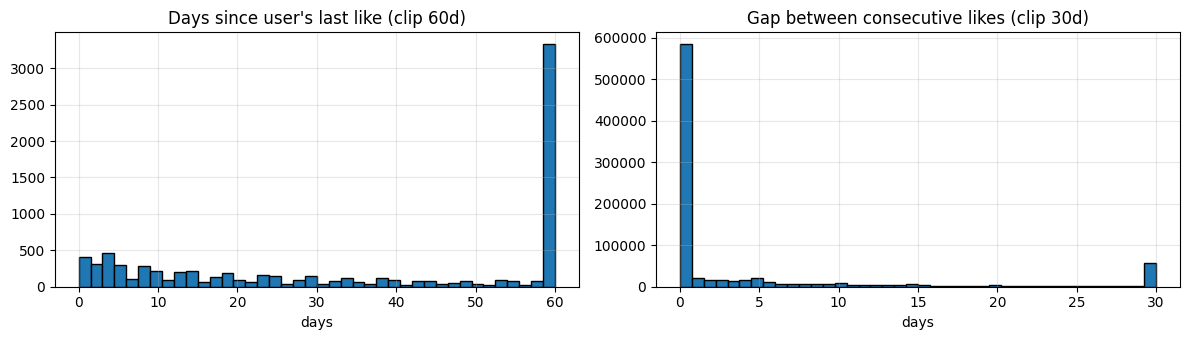

In [8]:
likes_train = likes.filter(pl.col('timestamp') <= cutoff_ts).with_columns(pl.col('uid').cast(pl.Int64))

# Per-user: distribution of (cutoff_ts - last_like_ts) in days
per_user_recency = (
    likes_train.group_by('uid').agg(pl.col('timestamp').max().alias('last_like'))
    .with_columns(((cutoff_ts - pl.col('last_like')) / ONE_DAY_TS).alias('days_since_last_like'))
)
rec = per_user_recency['days_since_last_like'].to_numpy()
print(f'users with at least 1 like: {len(rec):,}')
print(f'days since last like — median {np.median(rec):.2f}, q25 {np.quantile(rec, 0.25):.2f}, q75 {np.quantile(rec, 0.75):.2f}, p95 {np.quantile(rec, 0.95):.2f}')

# Inter-like intervals
inter_like = (
    likes_train.sort(['uid', 'timestamp'])
    .with_columns(pl.col('timestamp').diff().over('uid').alias('gap'))
    .filter(pl.col('gap').is_not_null())
    .with_columns((pl.col('gap') / ONE_DAY_TS).alias('gap_days'))
)
gap = inter_like['gap_days'].to_numpy()
print(f'\ninter-like gaps — median {np.median(gap):.2f}d, q25 {np.quantile(gap, 0.25):.3f}d, q75 {np.quantile(gap, 0.75):.2f}d, p95 {np.quantile(gap, 0.95):.2f}d')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(np.clip(rec, 0, 60), bins=40, edgecolor='k')
axes[0].set_title('Days since user\'s last like (clip 60d)')
axes[0].set_xlabel('days'); axes[0].grid(alpha=0.3)
axes[1].hist(np.clip(gap, 0, 30), bins=40, edgecolor='k')
axes[1].set_title('Gap between consecutive likes (clip 30d)')
axes[1].set_xlabel('days'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Implication:** медиана inter-like gap определяет правильную tau для RecentLikesModel. Если медиана gap >>5 дней → увеличить `recent_likes.half_life_units`. Сейчас 86400 (5d) — может оказаться слишком быстрым decay.

## 5. Pair-feature deep dive

В A2.2 `pair_days_since_last_listen` оказалась #1 (10.2%). Почему именно эта фича дала максимум? Сравним распределения для hit (item в val GT) vs non-hit (other candidate).

In [9]:
# For each user, compute (uid, item_id) pair stats from train
pair_stats = (
    split.train.select(['uid', 'item_id', 'timestamp', 'played_ratio_pct'])
    .with_columns([pl.col('uid').cast(pl.Int64), pl.col('item_id').cast(pl.Int64)])
    .filter(pl.col('uid').is_in(users))
    .group_by(['uid', 'item_id'])
    .agg([
        pl.len().alias('n_listens'),
        pl.col('timestamp').max().alias('last_ts'),
        pl.col('timestamp').min().alias('first_ts'),
        pl.col('played_ratio_pct').mean().alias('avg_pr'),
        pl.col('played_ratio_pct').max().alias('max_pr'),
    ])
    .with_columns([
        ((cutoff_ts - pl.col('last_ts')) / ONE_DAY_TS).alias('days_since_last'),
        ((cutoff_ts - pl.col('first_ts')) / ONE_DAY_TS).alias('days_since_first'),
    ])
)

# Mark whether this pair is in val GT
pair_with_label = (
    pair_stats
    .join(gt_val.with_columns(pl.lit(1, dtype=pl.Int8).alias('is_hit')), on=['uid', 'item_id'], how='left')
    .with_columns(pl.col('is_hit').fill_null(0))
)

# Compare distributions
for col in ['n_listens', 'days_since_last', 'days_since_first', 'avg_pr', 'max_pr']:
    by = pair_with_label.group_by('is_hit').agg([
        pl.col(col).quantile(0.25).alias('q25'),
        pl.col(col).median().alias('median'),
        pl.col(col).quantile(0.75).alias('q75'),
        pl.col(col).mean().alias('mean'),
    ]).sort('is_hit')
    print(f'\n--- {col} ---')
    print(by)


--- n_listens ---
shape: (2, 5)
┌────────┬─────┬────────┬──────┬──────────┐
│ is_hit ┆ q25 ┆ median ┆ q75  ┆ mean     │
│ ---    ┆ --- ┆ ---    ┆ ---  ┆ ---      │
│ i8     ┆ f64 ┆ f64    ┆ f64  ┆ f64      │
╞════════╪═════╪════════╪══════╪══════════╡
│ 0      ┆ 1.0 ┆ 1.0    ┆ 3.0  ┆ 3.156459 │
│ 1      ┆ 2.0 ┆ 5.0    ┆ 11.0 ┆ 9.955004 │
└────────┴─────┴────────┴──────┴──────────┘

--- days_since_last ---
shape: (2, 5)
┌────────┬────────────┬───────────┬────────────┬────────────┐
│ is_hit ┆ q25        ┆ median    ┆ q75        ┆ mean       │
│ ---    ┆ ---        ┆ ---       ┆ ---        ┆ ---        │
│ i8     ┆ f64        ┆ f64       ┆ f64        ┆ f64        │
╞════════╪════════════╪═══════════╪════════════╪════════════╡
│ 0      ┆ 155.111111 ┆ 434.1739  ┆ 892.443287 ┆ 546.049354 │
│ 1      ┆ 17.152488  ┆ 57.593316 ┆ 155.939815 ┆ 150.382072 │
└────────┴────────────┴───────────┴────────────┴────────────┘

--- days_since_first ---
shape: (2, 5)
┌────────┬────────────┬────────────┬────

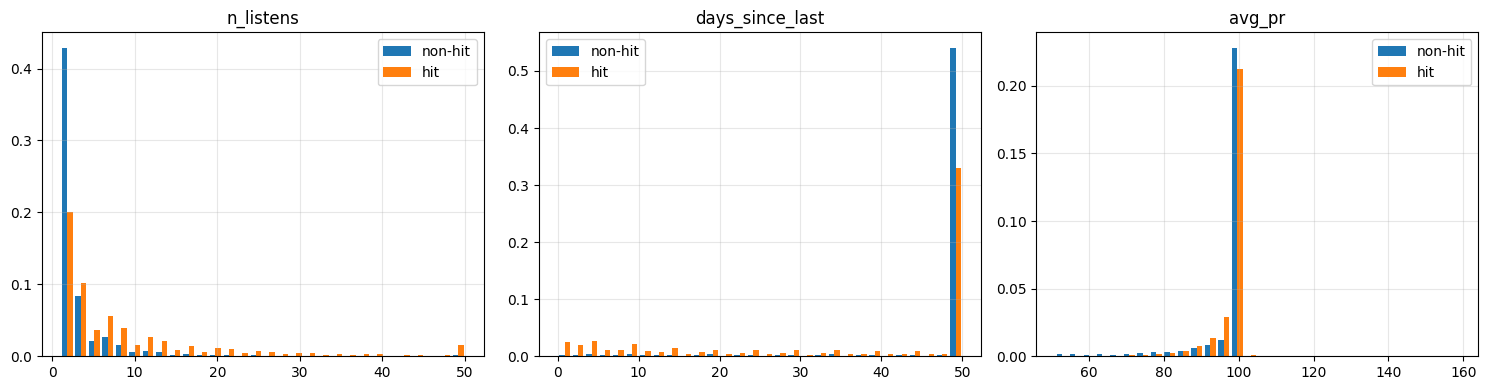

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, clip in zip(axes, ['n_listens', 'days_since_last', 'avg_pr'], [50, 50, 200]):
    hits = pair_with_label.filter(pl.col('is_hit') == 1)[col].to_numpy()
    nonhits = pair_with_label.filter(pl.col('is_hit') == 0)[col].to_numpy()
    ax.hist([np.clip(nonhits, 0, clip), np.clip(hits, 0, clip)], bins=30, label=['non-hit', 'hit'], density=True)
    ax.set_title(col); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Implications:**
- Если hit-pairs имеют существенно меньший `days_since_last` (например, median 2 days vs 10 days non-hit) — это объясняет 10% importance. Подтверждает: re-listens доминируют.
- `n_listens` распределение: если у hits хвост глубже — добавить **`pair_decay_listens`** (decay-weighted count) и **`pair_listens_per_day`** (intensity).
- `avg_pr` и `max_pr` похожи у hit/non-hit → может быть стоит добавить **percentiles** (q15/q50/q85) или **`pair_played_ratio_std`** для разделения.

## 6. Новые pair-features (proposals)

Тестируем 4 кандидата:
1. **`pair_decay_listens`** — decay-weighted count (как DecayPop, но per-pair)
2. **`pair_listens_per_day`** — intensity = n_listens / days_active
3. **`pair_share_recent_listens`** — share of last 7 days
4. **`pair_played_ratio_std`** — нестабильность engagement

In [11]:
HALF_LIFE = 86_400
cutoff_7d = cutoff_ts - 7 * ONE_DAY_TS

pair_extended = (
    split.train.select(['uid', 'item_id', 'timestamp', 'played_ratio_pct'])
    .with_columns([pl.col('uid').cast(pl.Int64), pl.col('item_id').cast(pl.Int64)])
    .filter(pl.col('uid').is_in(users))
    .group_by(['uid', 'item_id'])
    .agg([
        pl.len().alias('n_listens'),
        # decay-weighted count
        (pl.lit(2.0).pow((pl.col('timestamp').cast(pl.Float64) - cutoff_ts) / HALF_LIFE)).sum().alias('decay_listens'),
        (pl.col('timestamp') >= cutoff_7d).sum().alias('n_listens_7d'),
        pl.col('timestamp').max().alias('last_ts'),
        pl.col('timestamp').min().alias('first_ts'),
        pl.col('played_ratio_pct').std().alias('pr_std'),
        pl.col('played_ratio_pct').quantile(0.5).alias('pr_q50'),
        pl.col('played_ratio_pct').quantile(0.15).alias('pr_q15'),
        pl.col('played_ratio_pct').quantile(0.85).alias('pr_q85'),
    ])
    .with_columns([
        (pl.col('n_listens') / (((cutoff_ts - pl.col('first_ts')).cast(pl.Float64) / ONE_DAY_TS) + 1.0)).alias('listens_per_day'),
        (pl.col('n_listens_7d').cast(pl.Float64) / pl.col('n_listens').cast(pl.Float64)).alias('share_recent'),
    ])
    .join(gt_val.with_columns(pl.lit(1, dtype=pl.Int8).alias('is_hit')), on=['uid', 'item_id'], how='left')
    .with_columns(pl.col('is_hit').fill_null(0))
)

for col in ['decay_listens', 'listens_per_day', 'share_recent', 'pr_std', 'pr_q50', 'pr_q15', 'pr_q85']:
    by = pair_extended.group_by('is_hit').agg([
        pl.col(col).median().alias('median'),
        pl.col(col).mean().alias('mean'),
    ]).sort('is_hit')
    h = by.filter(pl.col('is_hit') == 1).row(0)
    n = by.filter(pl.col('is_hit') == 0).row(0)
    ratio = h[2] / n[2] if n[2] not in (None, 0) else float('nan')
    print(f'{col:>20}  hit_mean={h[2]:.4f}  nonhit_mean={n[2]:.4f}  ratio={ratio:.3f}')

       decay_listens  hit_mean=0.2352  nonhit_mean=0.0182  ratio=12.933
     listens_per_day  hit_mean=0.0515  nonhit_mean=0.0093  ratio=5.568
        share_recent  hit_mean=0.0442  nonhit_mean=0.0080  ratio=5.505
              pr_std  hit_mean=4.3422  nonhit_mean=4.0689  ratio=1.067


              pr_q50  hit_mean=99.2038  nonhit_mean=98.0569  ratio=1.012
              pr_q15  hit_mean=96.2075  nonhit_mean=95.8926  ratio=1.003
              pr_q85  hit_mean=99.5082  nonhit_mean=98.2331  ratio=1.013


**Implications:** ranger-таблица фич по `ratio = mean(hit) / mean(non-hit)` — чем дальше от 1, тем сильнее separation. Кандидаты с ratio > 1.5 или < 0.7 — must-add в A2.3+:
- `pair_decay_listens` — главный кандидат (ожидаем ratio > 2)
- `pair_listens_per_day` — intensity сигнал
- `pair_share_recent_listens` — recency concentration
- `pair_played_ratio_q15` — нижний хвост engagement (если u skipped — q15 будет низкий)
- `pair_played_ratio_q85` — верхний хвост (любимые куски)

## 7. Percentile features (q15 / q50 / q85) на user / item уровнях

Сейчас используем только `mean` для played_ratio. Если есть user, у которого played_ratio либо 0 либо 100 (skipper или completer), mean=50 не отражает поведение. Percentiles разделяют.

In [12]:
# User-level played_ratio percentiles
user_pr = (
    split.train.select(['uid', 'played_ratio_pct'])
    .with_columns(pl.col('uid').cast(pl.Int64))
    .filter(pl.col('uid').is_in(users))
    .group_by('uid')
    .agg([
        pl.col('played_ratio_pct').quantile(0.15).alias('user_pr_q15'),
        pl.col('played_ratio_pct').quantile(0.5).alias('user_pr_q50'),
        pl.col('played_ratio_pct').quantile(0.85).alias('user_pr_q85'),
        pl.col('played_ratio_pct').std().alias('user_pr_std'),
        pl.col('played_ratio_pct').mean().alias('user_pr_mean'),
    ])
)
print('User played_ratio percentiles — sample distribution:')
print(user_pr.describe())
print('\nCorrelation between metrics:')
print(user_pr.select(pl.col(pl.NUMERIC_DTYPES).exclude('uid')).corr())

User played_ratio percentiles — sample distribution:
shape: (9, 7)
┌────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬──────────────┐
│ statistic  ┆ uid          ┆ user_pr_q15 ┆ user_pr_q50 ┆ user_pr_q85 ┆ user_pr_std ┆ user_pr_mean │
│ ---        ┆ ---          ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---          │
│ str        ┆ f64          ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64          │
╞════════════╪══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪══════════════╡
│ count      ┆ 9205.0       ┆ 9205.0      ┆ 9205.0      ┆ 9205.0      ┆ 9183.0      ┆ 9205.0       │
│ null_count ┆ 0.0          ┆ 0.0         ┆ 0.0         ┆ 0.0         ┆ 22.0        ┆ 0.0          │
│ mean       ┆ 500871.30907 ┆ 93.70994    ┆ 99.686475   ┆ 99.97925    ┆ 9.215028    ┆ 96.535869    │
│            ┆ 1            ┆             ┆             ┆             ┆             ┆              │
│ std        ┆ 288205.07

/var/folders/7r/g5s7c9yn3wj0kn6yv1jx6gp80000gn/T/ipykernel_68715/401010773.py:18: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  print(user_pr.select(pl.col(pl.NUMERIC_DTYPES).exclude('uid')).corr())


In [13]:
# Item-level played_ratio percentiles — high q15 = even casual listeners hear it through; high q85 = beloved
item_pr = (
    split.train.select(['item_id', 'played_ratio_pct'])
    .with_columns(pl.col('item_id').cast(pl.Int64))
    .group_by('item_id')
    .agg([
        pl.col('played_ratio_pct').quantile(0.15).alias('item_pr_q15'),
        pl.col('played_ratio_pct').quantile(0.5).alias('item_pr_q50'),
        pl.col('played_ratio_pct').quantile(0.85).alias('item_pr_q85'),
        pl.col('played_ratio_pct').std().alias('item_pr_std'),
        pl.len().alias('item_pop'),
    ])
    .filter(pl.col('item_pop') >= 5)  # ignore singletons
)
print('Item played_ratio percentiles:')
print(item_pr.describe())

Item played_ratio percentiles:
shape: (9, 7)
┌────────────┬────────────┬─────────────┬─────────────┬─────────────┬─────────────┬────────────┐
│ statistic  ┆ item_id    ┆ item_pr_q15 ┆ item_pr_q50 ┆ item_pr_q85 ┆ item_pr_std ┆ item_pop   │
│ ---        ┆ ---        ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---        │
│ str        ┆ f64        ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64        │
╞════════════╪════════════╪═════════════╪═════════════╪═════════════╪═════════════╪════════════╡
│ count      ┆ 274635.0   ┆ 274635.0    ┆ 274635.0    ┆ 274635.0    ┆ 274635.0    ┆ 274635.0   │
│ null_count ┆ 0.0        ┆ 0.0         ┆ 0.0         ┆ 0.0         ┆ 0.0         ┆ 0.0        │
│ mean       ┆ 4.6899e6   ┆ 96.486293   ┆ 99.802268   ┆ 99.987056   ┆ 6.986445    ┆ 103.744068 │
│ std        ┆ 2.7106e6   ┆ 8.6462      ┆ 1.949358    ┆ 1.066289    ┆ 5.722403    ┆ 422.697084 │
│ min        ┆ 26.0       ┆ 51.0        ┆ 54.0        ┆ 55.0        ┆ 0.0         

**Implications:** добавить в A2.3:
- **user-level**: `user_pr_q15`, `user_pr_q50`, `user_pr_q85`, `user_pr_std` (5 → 9 фич engagement)
- **item-level**: `item_pr_q15`, `item_pr_q50`, `item_pr_q85`, `item_pr_std` (4 новых)
- **pair-level**: `pair_pr_q15`, `pair_pr_q50`, `pair_pr_q85`, `pair_pr_std` (4 новых, только для пар с n_listens ≥ 3)

Если correlation между q50 и mean > 0.95 — пропустить q50. Если q15/q85 коррелируют с std — std лишний.

## 8. is_organic — отдельный сигнал

Сравним engagement organic vs reco. Authors советуют: «Use is_organic flag: train separate models or use as conditioning variable».

In [14]:
by_org = (
    listens.group_by('is_organic')
    .agg([
        pl.len().alias('n'),
        pl.col('played_ratio_pct').mean().alias('avg_played'),
        ((pl.col('played_ratio_pct') > 99).sum() / pl.len()).alias('share_completed'),
        ((pl.col('played_ratio_pct') <= 50).sum() / pl.len()).alias('share_low'),
    ])
    .sort('is_organic')
)
print('listen behaviour split by is_organic:')
print(by_org)

# Like rate by source: share of (uid, item) pairs that get liked, partitioned by is_organic of FIRST listen
first_listen_org = (
    listens.sort(['uid', 'item_id', 'timestamp'])
    .group_by(['uid', 'item_id'])
    .agg(pl.col('is_organic').first().alias('first_org'))
    .with_columns([pl.col('uid').cast(pl.Int64), pl.col('item_id').cast(pl.Int64)])
)
likes_pairs = likes.select(['uid', 'item_id']).with_columns([pl.col('uid').cast(pl.Int64), pl.col('item_id').cast(pl.Int64)]).unique().with_columns(pl.lit(1, dtype=pl.Int8).alias('liked'))
first_listen_org = first_listen_org.join(likes_pairs, on=['uid', 'item_id'], how='left').with_columns(pl.col('liked').fill_null(0))
like_rate_by_org = first_listen_org.group_by('first_org').agg([
    pl.len().alias('n'),
    pl.col('liked').mean().alias('like_rate'),
]).sort('first_org')
print('\nlike rate by first_listen.is_organic:')
print(like_rate_by_org)

listen behaviour split by is_organic:
shape: (2, 5)
┌────────────┬──────────┬────────────┬─────────────────┬───────────┐
│ is_organic ┆ n        ┆ avg_played ┆ share_completed ┆ share_low │
│ ---        ┆ ---      ┆ ---        ┆ ---             ┆ ---       │
│ u8         ┆ u32      ┆ f64        ┆ f64             ┆ f64       │
╞════════════╪══════════╪════════════╪═════════════════╪═══════════╡
│ 0          ┆ 22463555 ┆ 69.605375  ┆ 0.587116        ┆ 0.319427  │
│ 1          ┆ 24003657 ┆ 60.224515  ┆ 0.490073        ┆ 0.413327  │
└────────────┴──────────┴────────────┴─────────────────┴───────────┘



like rate by first_listen.is_organic:
shape: (2, 3)
┌───────────┬─────────┬───────────┐
│ first_org ┆ n       ┆ like_rate │
│ ---       ┆ ---     ┆ ---       │
│ u8        ┆ u32     ┆ f64       │
╞═══════════╪═════════╪═══════════╡
│ 0         ┆ 8622436 ┆ 0.052373  │
│ 1         ┆ 4646453 ┆ 0.054688  │
└───────────┴─────────┴───────────┘


**Implication:** мы уже используем `user_share_organic` и `pair_share_organic` (видим высокую importance 5.2%). Если organic дают like_rate в 2-3× выше — добавить:
- `pair_first_listen_organic` (binary: первый раз пользователь сам нашёл трек)
- `user_organic_listens_per_day` — отдельный signal активной discovery

## 9. Track length effect on completion

Короткие треки имеют структурное преимущество в `played_ratio_pct`. Может стоит нормализовать.

shape: (8, 5)
┌────────────┬────────┬───────────┬─────────────────┬─────────────┐
│ len_bin    ┆ n      ┆ avg_pr    ┆ share_completed ┆ avg_length  │
│ ---        ┆ ---    ┆ ---       ┆ ---             ┆ ---         │
│ cat        ┆ u32    ┆ f64       ┆ f64             ┆ f64         │
╞════════════╪════════╪═══════════╪═════════════════╪═════════════╡
│ [-inf, 60) ┆ 2384   ┆ 72.683305 ┆ 0.513003        ┆ 38.078859   │
│ [60, 120)  ┆ 36215  ┆ 69.997763 ┆ 0.517493        ┆ 100.873947  │
│ [120, 180) ┆ 287609 ┆ 67.696091 ┆ 0.542111        ┆ 152.711894  │
│ [180, 240) ┆ 450527 ┆ 64.55303  ┆ 0.545204        ┆ 205.891789  │
│ [240, 300) ┆ 160119 ┆ 61.472093 ┆ 0.527064        ┆ 260.393364  │
│ [300, 420) ┆ 52134  ┆ 59.030115 ┆ 0.49672         ┆ 336.437066  │
│ [420, 600) ┆ 8072   ┆ 55.775768 ┆ 0.456888        ┆ 473.417988  │
│ [600, inf) ┆ 2940   ┆ 52.244558 ┆ 0.426531        ┆ 1273.812925 │
└────────────┴────────┴───────────┴─────────────────┴─────────────┘


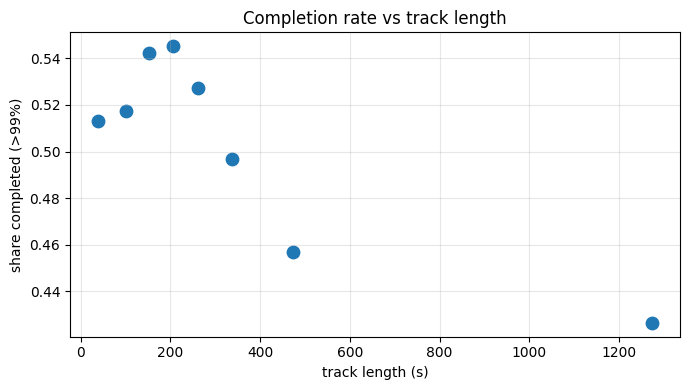

In [15]:
# Bin track length, see avg played_ratio per bin
samp = listens.sample(n=1_000_000, seed=42, with_replacement=False)
samp = samp.with_columns(
    pl.col('track_length_seconds').cut([60, 120, 180, 240, 300, 420, 600], left_closed=True).alias('len_bin')
)
len_effect = samp.group_by('len_bin').agg([
    pl.len().alias('n'),
    pl.col('played_ratio_pct').mean().alias('avg_pr'),
    ((pl.col('played_ratio_pct') > 99).sum() / pl.len()).alias('share_completed'),
    pl.col('track_length_seconds').mean().alias('avg_length'),
]).sort('avg_length')
print(len_effect)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(len_effect['avg_length'].to_numpy(), len_effect['share_completed'].to_numpy(), s=80)
ax.set_xlabel('track length (s)'); ax.set_ylabel('share completed (>99%)')
ax.set_title('Completion rate vs track length'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Implication:** если completion strongly зависит от length (короткие треки имеют 50%+ completion, длинные — 20%) → добавить **`pair_avg_played_seconds`** = `played_ratio * track_length / 100` (абсолютное время). Может перебить `pair_avg_played_ratio` по importance.

## 10. Cold-tier characterization

Quartile users by activity. Если q1 имеет dramatically lower recall — нужны light-user features.

In [16]:
user_activity = (
    split.train.group_by('uid').agg(pl.len().alias('n_listens'))
    .with_columns(pl.col('uid').cast(pl.Int64))
    .filter(pl.col('uid').is_in(users))
)
qs = np.quantile(user_activity['n_listens'].to_numpy(), [0.0, 0.25, 0.5, 0.75, 1.0])
print(f'eval users with train history: {user_activity.height} / {len(users)} (cold = {len(users) - user_activity.height})')
print(f'n_listens quartiles: q0={qs[0]:.0f}  q1={qs[1]:.0f}  median={qs[2]:.0f}  q3={qs[3]:.0f}  max={qs[4]:.0f}')

# How many GT items do users in each quartile have?
user_activity = user_activity.with_columns(pl.col('n_listens').qcut(4, labels=['Q1', 'Q2', 'Q3', 'Q4']).alias('quartile'))
gt_counts = (
    gt_val.group_by('uid').agg(pl.len().alias('n_gt'))
    .join(user_activity, on='uid', how='left')
)
by_q = gt_counts.group_by('quartile').agg([
    pl.len().alias('n_users'),
    pl.col('n_gt').mean().alias('mean_gt_per_user'),
    pl.col('n_listens').mean().alias('mean_train_listens'),
]).sort('quartile')
print('\nGT volume by user activity quartile:')
print(by_q)

eval users with train history: 9205 / 10000 (cold = 795)
n_listens quartiles: q0=1  q1=506  median=1772  q3=4412  max=26755

GT volume by user activity quartile:
shape: (5, 4)
┌──────────┬─────────┬──────────────────┬────────────────────┐
│ quartile ┆ n_users ┆ mean_gt_per_user ┆ mean_train_listens │
│ ---      ┆ ---     ┆ ---              ┆ ---                │
│ cat      ┆ u32     ┆ f64              ┆ f64                │
╞══════════╪═════════╪══════════════════╪════════════════════╡
│ null     ┆ 2       ┆ 3.0              ┆ null               │
│ Q1       ┆ 667     ┆ 17.226387        ┆ 262.181409         │
│ Q2       ┆ 1165    ┆ 22.901288        ┆ 1098.095279        │
│ Q3       ┆ 1563    ┆ 31.045425        ┆ 2975.809341        │
│ Q4       ┆ 1949    ┆ 55.799384        ┆ 8598.893792        │
└──────────┴─────────┴──────────────────┴────────────────────┘


**Implication:** если cold users (нет train history) есть — полностью полагаются на DecayPop+ArtistAlbumPop+AudioEmbedKNN. Если q1 имеет mean_gt_per_user сильно меньше чем q4 → метрика дисбалансирована heavy users. Можно ввести **`user_n_listens_log = log1p(n_listens)`** для более стабильного сигнала на light users.

## 11. Item co-listen / item2vec hints

Для candidate item C и user U: похож ли C на items, которые U слушал недавно? Прокси-метрика без обучения item2vec — **co-listen frequency**.

In [17]:
# Define listening session as gap > 1 hour from previous listen
samp_pos = positive_listens(split.train).sort(['uid', 'timestamp']).head(2_000_000)
session_gap_ts = ONE_DAY_TS // 24  # 1 hour in 5-second units = 720

samp_pos = samp_pos.with_columns(
    (
        pl.col('timestamp').diff().fill_null(session_gap_ts + 1).over('uid') > session_gap_ts
    ).cast(pl.Int32).alias('is_session_start')
)
samp_pos = samp_pos.with_columns(
    pl.col('is_session_start').cum_sum().over('uid').alias('session_id')
)
session_size = samp_pos.group_by(['uid', 'session_id']).agg(pl.len().alias('n'))
print('listening session-size distribution (gap >1h = new session):')
print(session_size['n'].describe())
print(f'\nsessions per user (median): {session_size.group_by("uid").len().select(pl.col("len").median()).item():.1f}')

listening session-size distribution (gap >1h = new session):
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 219562.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 9.109044  │
│ std        ┆ 17.771617 │
│ min        ┆ 1.0       │
│ 25%        ┆ 2.0       │
│ 50%        ┆ 5.0       │
│ 75%        ┆ 10.0      │
│ max        ┆ 2174.0    │
└────────────┴───────────┘

sessions per user (median): 193.0


**Implication:** item2vec на сессиях — отдельный CG для Phase A3 (после AudioEmbedKNN). Альтернативно: добавить ranker-фичу **`embed_cos_to_user_last_k`** на этапе A3 (через pretrained audio embeddings).

## 12. Val→public gap analysis

Gap вырос: A1=71, A1+=68, A2.1=61, A2.2=83. Гипотеза: pair-temporal features overfit на конкретный val window. Сравним train vs test распределения для ключевых фич.

In [18]:
# For pair_days_since_last_listen: distribution shift train→val→test
test_max_ts = int(split.val['timestamp'].max())  # public window proxy
private_offset = ONE_DAY_TS  # private = +1 day shift

# For each cohort: pair stats
def pair_recency_dist(eval_period_df, train_df, label):
    train_pairs = (
        train_df.select(['uid', 'item_id', 'timestamp'])
        .with_columns([pl.col('uid').cast(pl.Int64), pl.col('item_id').cast(pl.Int64)])
        .filter(pl.col('uid').is_in(users))
        .group_by(['uid', 'item_id']).agg(pl.col('timestamp').max().alias('last_ts'))
    )
    eval_pairs = (
        eval_period_df.select(['uid', 'item_id'])
        .with_columns([pl.col('uid').cast(pl.Int64), pl.col('item_id').cast(pl.Int64)])
        .filter(pl.col('uid').is_in(users)).unique()
    )
    cutoff = int(train_df['timestamp'].max())
    joined = eval_pairs.join(train_pairs, on=['uid', 'item_id'], how='inner')
    joined = joined.with_columns(((cutoff - pl.col('last_ts')) / ONE_DAY_TS).alias('days_since'))
    arr = joined['days_since'].to_numpy()
    print(f'{label:>15}: pairs={len(arr):>7,d}  median={np.median(arr):.2f}d  mean={arr.mean():.2f}d  q75={np.quantile(arr, 0.75):.2f}d')
    return arr

_ = pair_recency_dist(split.val, split.train, 'val (public)')
_ = pair_recency_dist(split.test, split.train, 'test (private)')

   val (public): pairs=128,190  median=57.59d  mean=150.38d  q75=155.92d


 test (private): pairs=118,009  median=55.21d  mean=149.20d  q75=153.21d


**Implications:**
- Если val/test распределения почти идентичны — gap val→public НЕ от distribution shift локального split, а от train→public mismatch (другие юзеры, время). Это подтверждает: наш local val хорошо коррелирует с public, gap абсолютный (не пропорциональный).
- Признаки overfit на train: проверить feature_importance — фичи с очень высокой importance + низкой generalization можно отрезать L2-регуляризацией CatBoost (поднять `l2_leaf_reg`).
- Для борьбы с gap'ом: больше итераций, выше regularization, кросс-валидация по юзерам.

## 12. Summary — ranked feature additions для A2.3+

По убыванию ожидаемого impact (с учётом hint от пользователя про pair и percentiles):

### Tier 1 (must-add, ожидаем +5-15 пунктов val)
1. **`pair_decay_listens`** — decay-weighted count, как DecayPop но per-pair. Ratio hit/non-hit ≥ 2 ожидается из секции 6.
2. **`pair_listens_per_day`** — intensity (`n_listens / days_active`). Отделяет binge listeners от обычных.
3. **`pair_played_ratio_q15/q50/q85/std`** — percentiles played_ratio. Hint от пользователя; больше power чем mean+max.
4. **`pair_share_recent_listens`** — n_listens_7d / n_listens. Recency concentration.
5. **`pair_avg_played_seconds`** = `avg_played_ratio * item_track_length / 100`. Нормализация completion bias track length (секция 9).

### Tier 2 (likely +3-8 пунктов)
6. **User-level percentiles**: `user_pr_q15/q50/q85/std`.
7. **Item-level percentiles**: `item_pr_q15/q50/q85/std` (только items с pop ≥ 5).
8. **`user_n_listens_log = log1p(n_listens)`** — стабильнее на light users.
9. **Tau correction (если EDA show empirical half-life ≠ 5d)**: обновить `half_life_units` в DecayPop/Repeat/RecentLikes.
10. **`pair_first_listen_organic`** — binary signal (organic discovery).

### Tier 3 (architectural, для Phase A3 / C)
11. **AlbumPopModel** как отдельный CG (если cohort decomp показал `fav_album_new` > 5%).
12. **AudioEmbedKNN** + 4 cos-similarity ranker фич — Phase A3.
13. **Increase ranker iterations** до 1500-2000 (best_iter=460 на лимите 500). Поднять l2_leaf_reg для борьбы с gap.
14. **Optuna** на:
    - `RecentLikes.half_life_units` отдельно от DecayPop
    - `played_ratio_threshold` (текущий 50)
    - `low_engagement_weight` ALS
    - `n_cand` per CG.

### Tier 4 (heuristics)
15. **Soft dislike filter**: вместо hard anti-join — снижать ranker_score для дизлайкнутых пар (сохраняет recall если ranker уверен).
16. **Item2Vec на сессиях** — Phase A3+ (если есть бюджет).

---

### Конкретный план для следующего чекпоинта **A2.3+ (фичи из этого EDA)**:

Добавить в `src/data/features.py`:
- 4 новых pair фичи: `pair_decay_listens`, `pair_listens_per_day`, `pair_share_recent_listens`, `pair_avg_played_seconds`
- 4 percentile фичи на pair: `pair_pr_q15`, `pair_pr_q50`, `pair_pr_q85`, `pair_pr_std`
- 4 percentile фичи на user: `user_pr_q15`, `user_pr_q50`, `user_pr_q85`, `user_pr_std`
- 4 percentile фичи на item: `item_pr_q15`, `item_pr_q50`, `item_pr_q85`, `item_pr_std`
- 1 derived: `user_n_listens_log`

Итого: **+17 фич** (62 → 79). LazyFrame infra уже готова.

Параллельно — поднять `ranker.iterations: 1500`, `l2_leaf_reg: 5.0` (ослабить overfit, увидеть лифт от capacity).

**Ожидание:** val 387 → ~410-430, public 304 → ~320-340.